# 🏅 Olympics Data Analysis

This notebook focuses on exploring historical Olympic data from 1896 to 2016 to understand patterns in athlete participation, medal distribution, and country performance over time.

Instead of just visualizing the data, the aim here is to dig deeper and answer questions like:
- How participation has changed across different eras  
- Which countries and athletes have consistently performed well  
- How athlete characteristics such as age, height, and weight vary across sports  
- What trends can be observed in medal distribution over time  

The dataset used in this analysis is sourced from Kaggle. It has been cleaned and processed step-by-step to ensure reliable insights.

This notebook serves as the analytical foundation for a Streamlit dashboard built on top of it.

### Define Custom Package path in sys.path

In [1]:
import os
projectPath = os.path.abspath('..')

In [2]:
import sys
paths = sys.path
if sys.path.count(projectPath)==0:
    paths.append(projectPath)
else:
    pass
paths

['C:\\Users\\Sumit_Maulekhi\\AppData\\Local\\Programs\\Python\\Python314\\python314.zip',
 'C:\\Users\\Sumit_Maulekhi\\AppData\\Local\\Programs\\Python\\Python314\\DLLs',
 'C:\\Users\\Sumit_Maulekhi\\AppData\\Local\\Programs\\Python\\Python314\\Lib',
 'C:\\Users\\Sumit_Maulekhi\\AppData\\Local\\Programs\\Python\\Python314',
 'C:\\Users\\Sumit_Maulekhi\\AI_ML_WorkSpace\\python\\venv',
 '',
 'C:\\Users\\Sumit_Maulekhi\\AI_ML_WorkSpace\\python\\venv\\Lib\\site-packages',
 'C:\\Users\\Sumit_Maulekhi\\AI_ML_WorkSpace\\python\\olympics_data_analysis']

## Importing Libraries

In [3]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
from src import helper as hp
from scipy import stats as ss
from src import analysis as an
import matplotlib.pyplot as plt
from src import data_loader as dl
from src import preprocessing as pp

This is a Custom-Package for Olympic Data Exploration


2026-04-18 14:26:07.366 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-04-18 14:26:07.371 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-04-18 14:26:07.374 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


C:\Users\Sumit_Maulekhi\AI_ML_WorkSpace\python\olympics_data_analysis\notebooks


In [4]:
%matplotlib inline 
#this ensures that all the graphs are properly displayed in the notebook

## Loading Dataset

In [5]:
os.getcwd()

'C:\\Users\\Sumit_Maulekhi\\AI_ML_WorkSpace\\python\\olympics_data_analysis\\notebooks'

In [6]:
projectPath = os.path.abspath('..')
adfp = os.path.join(projectPath , 'data' , 'raw_data','athlete_events.csv') #athlete data file path
rdfp = os.path.join(projectPath , 'data' , 'raw_data' , 'noc_regions.csv') #regions data file path
adfp

'C:\\Users\\Sumit_Maulekhi\\AI_ML_WorkSpace\\python\\olympics_data_analysis\\data\\raw_data\\athlete_events.csv'

In [7]:
adf = dl.load_athlete_data(adfp)
if(type(adf)==pd.DataFrame):
    print(adf.info())

<class 'pandas.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  str    
 2   Sex     271116 non-null  str    
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  str    
 7   NOC     271116 non-null  str    
 8   Games   271116 non-null  str    
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  str    
 11  City    271116 non-null  str    
 12  Sport   271116 non-null  str    
 13  Event   271116 non-null  str    
 14  Medal   39783 non-null   str    
dtypes: float64(3), int64(2), str(10)
memory usage: 56.6 MB
None


In [8]:
rdf = dl.load_region_data(rdfp)
if(type(rdf) == pd.DataFrame):
    print(rdf.info())

<class 'pandas.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   NOC     230 non-null    str  
 1   region  227 non-null    str  
 2   notes   21 non-null     str  
dtypes: str(3)
memory usage: 8.4 KB
None


## Data Preparation

In [9]:
df = pp.merge_athletes_to_region(adf,rdf)
df.head(3)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN


In [10]:
df = pp.fetch_summer_olympics(df)
df.info()

<class 'pandas.DataFrame'>
Index: 222552 entries, 0 to 271110
Data columns (total 17 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      222552 non-null  int64  
 1   Name    222552 non-null  str    
 2   Sex     222552 non-null  str    
 3   Age     213363 non-null  float64
 4   Height  170695 non-null  float64
 5   Weight  168698 non-null  float64
 6   Team    222552 non-null  str    
 7   NOC     222552 non-null  str    
 8   Games   222552 non-null  str    
 9   Year    222552 non-null  int64  
 10  Season  222552 non-null  str    
 11  City    222552 non-null  str    
 12  Sport   222552 non-null  str    
 13  Event   222552 non-null  str    
 14  Medal   34088 non-null   str    
 15  region  222182 non-null  str    
 16  notes   4401 non-null    str    
dtypes: float64(3), int64(2), str(12)
memory usage: 53.1 MB


### Data Cleaning

In [11]:
df.duplicated().sum()

np.int64(1385)

In [12]:
df = pp.remove_duplicate_rows(df)
df.duplicated().sum()

np.int64(0)

### Save Prepared Data

In [13]:
pdfp = os.path.join(projectPath , 'data','processed_data','cleaned_data.csv') #pdfp - prepared data file path
df.to_csv(pdfp)

## Medal Distribution of Athletes

In [14]:
df = pp.expanding_medal_column(df)
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,False,False,False
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,False,False,False
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN,False,False,False
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,False,True,False
26,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN,Netherlands,NaN,False,False,False


### Building region-wise Medal tally

In [15]:
df.info()

<class 'pandas.DataFrame'>
Index: 221167 entries, 0 to 271110
Data columns (total 20 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      221167 non-null  int64  
 1   Name    221167 non-null  str    
 2   Sex     221167 non-null  str    
 3   Age     212137 non-null  float64
 4   Height  170667 non-null  float64
 5   Weight  168661 non-null  float64
 6   Team    221167 non-null  str    
 7   NOC     221167 non-null  str    
 8   Games   221167 non-null  str    
 9   Year    221167 non-null  int64  
 10  Season  221167 non-null  str    
 11  City    221167 non-null  str    
 12  Sport   221167 non-null  str    
 13  Event   221167 non-null  str    
 14  Medal   34077 non-null   str    
 15  region  220797 non-null  str    
 16  notes   4397 non-null    str    
 17  Bronze  221167 non-null  bool   
 18  Gold    221167 non-null  bool   
 19  Silver  221167 non-null  bool   
dtypes: bool(3), float64(3), int64(2), str(12)
memory usage: 53.4 MB


In [16]:
medal_tally = an.building_medal_tally_by_region(df,'Overall','Overall')
medal_tally

,region,Gold,Silver,Bronze,Total
1,USA,1035,802,708,2545
2,Russia,592,498,487,1577
3,Germany,444,457,491,1392
4,UK,278,317,300,895
5,France,234,256,287,777
...,...,...,...,...,...
201,Vanuatu,0,0,0,0
202,"Virgin Islands, British",0,0,0,0
203,"Virgin Islands, US",0,1,0,1
204,Yemen,0,0,0,0


### Building region and year wise Medal Tally

In [17]:
df.info()

<class 'pandas.DataFrame'>
Index: 221167 entries, 0 to 271110
Data columns (total 20 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      221167 non-null  int64  
 1   Name    221167 non-null  str    
 2   Sex     221167 non-null  str    
 3   Age     212137 non-null  float64
 4   Height  170667 non-null  float64
 5   Weight  168661 non-null  float64
 6   Team    221167 non-null  str    
 7   NOC     221167 non-null  str    
 8   Games   221167 non-null  str    
 9   Year    221167 non-null  int64  
 10  Season  221167 non-null  str    
 11  City    221167 non-null  str    
 12  Sport   221167 non-null  str    
 13  Event   221167 non-null  str    
 14  Medal   34077 non-null   str    
 15  region  220797 non-null  str    
 16  notes   4397 non-null    str    
 17  Bronze  221167 non-null  bool   
 18  Gold    221167 non-null  bool   
 19  Silver  221167 non-null  bool   
dtypes: bool(3), float64(3), int64(2), str(12)
memory usage: 53.4 MB


In [18]:
country , year = hp.fetch_country_and_year(df)

In [19]:
selected_country = 'Russia'
selected_year = 2016
tally = an.building_medal_tally_by_region(df,selected_country,selected_year)
tally

,region,Gold,Silver,Bronze,Total
1,Russia,19,17,20,56


## Overall Analysis 

* no. of editions
* no. of cities
* no. of sports
* no. of events
* no. of athletes
* participating nations

In [20]:
edition = df['Year'].unique().shape[0]-1 #as olympic does not consider 1906 edition
edition

28

In [21]:
hosts = df['City'].unique().shape[0]
hosts

23

In [22]:
sports = df['Sport'].unique().shape[0]
sports

52

In [23]:
events = df['Event'].unique().shape[0]
events

651

In [24]:
athletes = df['ID'].unique().shape[0]
athletes

116776

In [25]:
nations = df['region'].unique().shape[0]
nations

206

### Participating Nations Over Time

In [26]:
nsot = df.groupby('Year')['region'].nunique() #nsot - nations over time
nsot = nsot.reset_index(name = 'Nations')
nsot.head()

,Year,Nations
0,1896,12
1,1900,31
2,1904,14
3,1906,20
4,1908,22


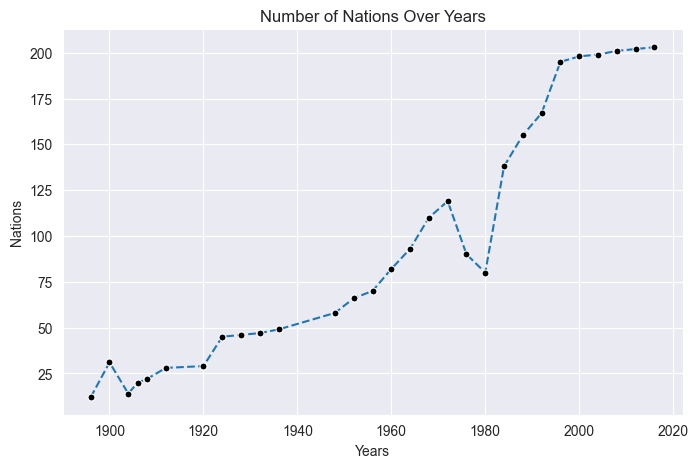

In [27]:
plt.figure(figsize=(8,5))

sns.set_style('dark')
sns.lineplot(data=nsot, x='Year', y='Nations',marker='.',ms=10,mfc='black',ls='dashed')
sns.despine()

plt.grid()
plt.title("Number of Nations Over Years")
plt.xlabel("Years")
plt.ylabel("Nations")

plt.show()

### Freqency of Events Over Time

In [28]:
neot = df.groupby('Year')['Event'].nunique() #neot - no. of events over time
neot = neot.reset_index(name='Events')
neot.head()

,Year,Events
0,1896,43
1,1900,90
2,1904,95
3,1906,74
4,1908,109


[]

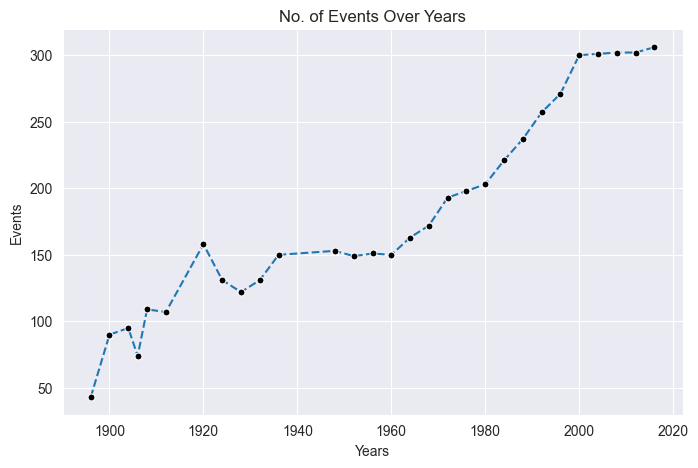

In [29]:
plt.figure(figsize=(8,5))

sns.set_style('dark')
sns.lineplot(data = neot , x = 'Year' , y = 'Events' , marker = '.' , ms = 10 , mfc = 'black' , ls = 'dashed')
sns.despine()

plt.grid()
plt.title('No. of Events Over Years')
plt.xlabel('Years')
plt.ylabel('Events')

plt.plot()

### Participation of Athletes Over Time

In [30]:
paot = df.groupby('Year')['ID'].nunique() #paot - participating athletes over time
paot = paot.reset_index(name='Athletes')
paot.head()

,Year,Athletes
0,1896,176
1,1900,1224
2,1904,650
3,1906,841
4,1908,2024


[]

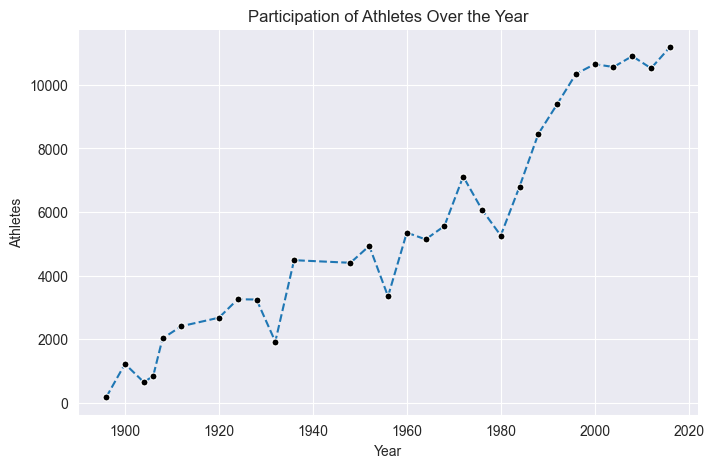

In [31]:
plt.figure(figsize=(8,5),edgecolor = 'red')

plt.title('Participation of Athletes Over the Year')

sns.set_style('dark')
sns.lineplot(paot,x='Year',y='Athletes',marker='.',mfc='black',ms=10,ls='dashed')
sns.despine()

plt.grid()

plt.plot()

### No. of Events for Sports Over the Year

In [32]:
aev = df.drop_duplicates(['Year','Sport','Event']) #aev - all events
aev.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,False,False,False
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,False,False,False
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN,False,False,False
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,False,True,False
26,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN,Netherlands,NaN,False,False,False


In [33]:
aev_pivot = aev.pivot_table(index = 'Sport',columns='Year',values='Event',aggfunc='count',fill_value=0).astype('int')
aev_pivot.head()

Year,1896,1900,1904,1906,1908,1912,1920,1924,1928,1932,...,1980,1984,1988,1992,1996,2000,2004,2008,2012,2016
Sport,,,,,,,,,,,,,,,,,,,,,
Aeronautics,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Alpinism,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
Archery,0,8,6,0,3,0,10,0,0,0,...,2,2,4,4,4,4,4,4,4,4
Art Competitions,0,0,0,0,0,5,5,5,13,13,...,0,0,0,0,0,0,0,0,0,0
Athletics,12,23,24,21,26,30,29,27,27,29,...,38,41,42,43,44,46,46,47,47,47


[]

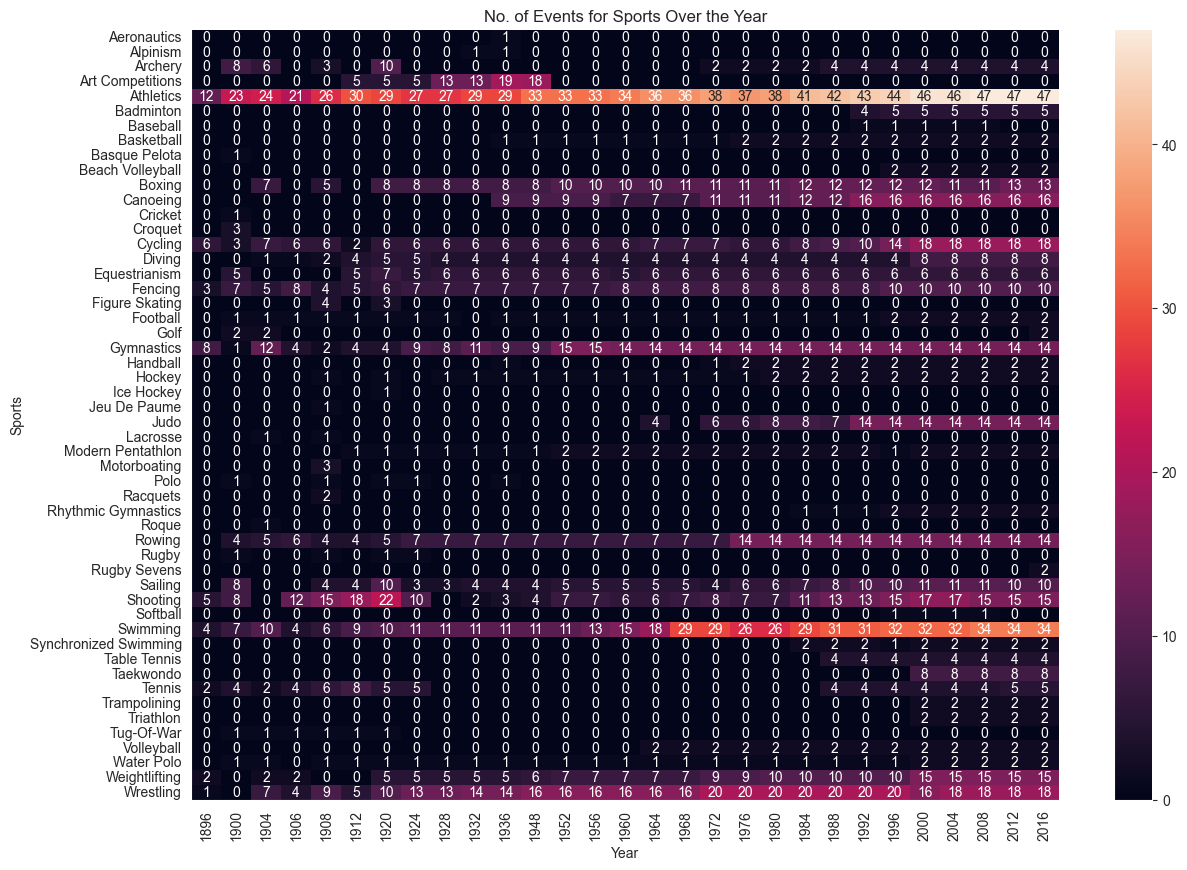

In [34]:
plt.figure(figsize=(14,10))

sns.set_style('dark')
sns.heatmap(aev_pivot,annot=True)
sns.despine()

plt.title('No. of Events for Sports Over the Year')
plt.xlabel('Year')
plt.ylabel('Sports')

plt.plot()

### Top Athletes of each Sport

In [35]:
top_athletes = an.top_athletes(df,'Overall')
top_athletes.head()

,Name,Sport,region,Medals
1,"Michael Fred Phelps, II",Swimming,USA,28
2,Larysa Semenivna Latynina (Diriy-),Gymnastics,Russia,18
3,Nikolay Yefimovich Andrianov,Gymnastics,Russia,15
4,Edoardo Mangiarotti,Fencing,Italy,13
5,Takashi Ono,Gymnastics,Japan,13


In [36]:
top_athletics_athletes = an.top_athletes(df,'Athletics')
top_athletics_athletes.head()

,Name,Sport,region,Medals
1,Paavo Johannes Nurmi,Athletics,Finland,12
2,"Raymond Clarence ""Ray"" Ewry",Athletics,USA,10
3,"Frederick Carlton ""Carl"" Lewis",Athletics,USA,10
4,Allyson Michelle Felix,Athletics,USA,9
5,Merlene Joyce Ottey-Page,Athletics,Jamaica,9


## Country-Wise Analysis

In [37]:
df.info()

<class 'pandas.DataFrame'>
Index: 221167 entries, 0 to 271110
Data columns (total 20 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      221167 non-null  int64  
 1   Name    221167 non-null  str    
 2   Sex     221167 non-null  str    
 3   Age     212137 non-null  float64
 4   Height  170667 non-null  float64
 5   Weight  168661 non-null  float64
 6   Team    221167 non-null  str    
 7   NOC     221167 non-null  str    
 8   Games   221167 non-null  str    
 9   Year    221167 non-null  int64  
 10  Season  221167 non-null  str    
 11  City    221167 non-null  str    
 12  Sport   221167 non-null  str    
 13  Event   221167 non-null  str    
 14  Medal   34077 non-null   str    
 15  region  220797 non-null  str    
 16  notes   4397 non-null    str    
 17  Bronze  221167 non-null  bool   
 18  Gold    221167 non-null  bool   
 19  Silver  221167 non-null  bool   
dtypes: bool(3), float64(3), int64(2), str(12)
memory usage: 53.4 MB


### Medal Won by Country Over the Year

In [38]:
team_df = df.dropna(subset='Medal')
team_df = team_df.drop_duplicates(subset=['Team','NOC','Games','Year','City','Sport','Event','Medal'])
team_df.reset_index(inplace=True)
team_df.head()

,index,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,...,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,...,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,False,True,False
1,37,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,...,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze,Finland,NaN,True,False,False
2,38,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,...,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze,Finland,NaN,True,False,False
3,41,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,...,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze,Finland,NaN,True,False,False
4,42,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,...,Summer,London,Gymnastics,Gymnastics Men's Team All-Around,Gold,Finland,NaN,False,True,False


In [39]:
country = 'India'
cwmt = team_df[team_df['region']==country] #cwmt - country wise medal tally
cwmt = cwmt.groupby('Year')['Medal'].count()
cwmt = cwmt.reset_index(name='Medals')
cwmt

,Year,Medals
0,1900,2
1,1928,1
2,1932,1
3,1936,1
4,1948,1
5,1952,2
6,1956,1
7,1960,1
8,1964,1
9,1968,1


[]

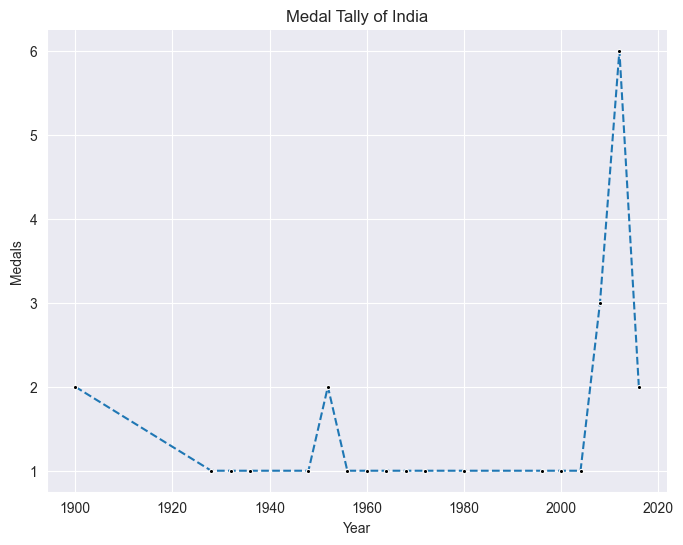

In [40]:
plt.figure(figsize=(8,6))

plt.title(f'Medal Tally of {country}')

sns.set_style('dark')
sns.lineplot(cwmt,x='Year',y='Medals',marker='.',mfc='black',ls='dashed')
sns.despine()

plt.grid()

plt.plot()

### Medal Won in Sports by a Country Over the Years

In [41]:
country = 'UK'
team_df = df.dropna(subset=['Medal'])
ctd = team_df.drop_duplicates(subset=['Team','NOC','Games','Year','City','Sport','Event','Medal']) #cleaned team dataframe

In [42]:
cmd = ctd[ctd['region']==country] #cmd - country medal dataframe
mcpfc = cmd.pivot_table(index='Sport',columns='Year',values='Medal',aggfunc='count',fill_value=0) #mcpfc - medal counts pivot for country
mcpfc.head()

Year,1896,1900,1904,1906,1908,1912,1920,1924,1928,1932,...,1980,1984,1988,1992,1996,2000,2004,2008,2012,2016
Sport,,,,,,,,,,,,,,,,,,,,,
Archery,0,0,0,0,5,0,0,0,0,0,...,0,0,1,2,0,0,1,0,0,0
Art Competitions,0,0,0,0,0,0,1,1,2,1,...,0,0,0,0,0,0,0,0,0,0
Athletics,2,9,2,9,17,8,12,11,5,8,...,10,16,8,6,6,6,4,5,6,7
Badminton,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,0,0,1
Boxing,0,0,0,0,14,0,6,4,0,0,...,1,1,1,1,0,1,1,3,5,3


[]

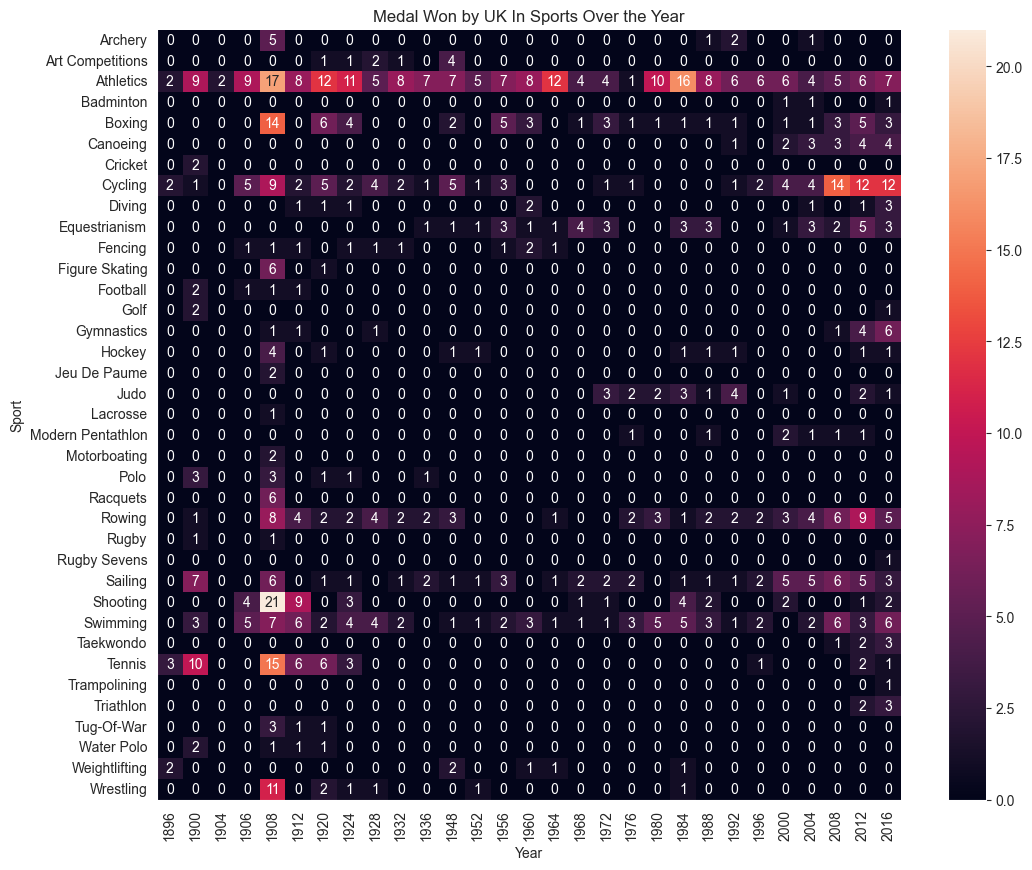

In [43]:
plt.figure(figsize=(12,10))

sns.set_style('dark')
sns.heatmap(mcpfc , annot=True)
sns.despine()

plt.title(f'Medal Won by {country} In Sports Over the Year')
plt.plot()

### Most Successfull Athletes In Sport of Country

In [44]:
country = 'UK'
team_df = df.dropna(subset=['Medal'])
team_df = team_df.drop_duplicates(subset=['Team','NOC','Games','Year','City','Sport','Event','Medal'])

In [45]:
cwdf = team_df[team_df['region']==country]  #cwdf - country-wise data frame
top_athletes = an.top_athletes(cwdf,'Overall')
top_athletes.head()

,Name,Sport,region,Medals
1,"Christopher Andrew ""Chris"" Hoy",Cycling,UK,6
2,"Charles Benedict ""Ben"" Ainslie",Sailing,UK,5
3,"Rebecca ""Becky"" Adlington",Swimming,UK,4
4,"Sebastian Newbold ""Seb"" Coe",Athletics,UK,4
5,Margaret Joyce Cooper (-Badcock),Swimming,UK,4


In [46]:
top_athletes_in_swimming = an.top_athletes(cwdf,'Swimming')
top_athletes_in_swimming.head()

,Name,Sport,region,Medals
1,"Rebecca ""Becky"" Adlington",Swimming,UK,4
2,Margaret Joyce Cooper (-Badcock),Swimming,UK,4
3,John Arthur Jarvis,Swimming,UK,4
4,Henry Taylor,Swimming,UK,4
5,David Andrew Wilkie,Swimming,UK,3


## Athlete-wise Analysis 

### Age Distribution of Athletes

In [47]:
ua = df.drop_duplicates() #ua - unique athletes
age = ua['Age'].dropna()
age.skew()

np.float64(1.595614822767566)

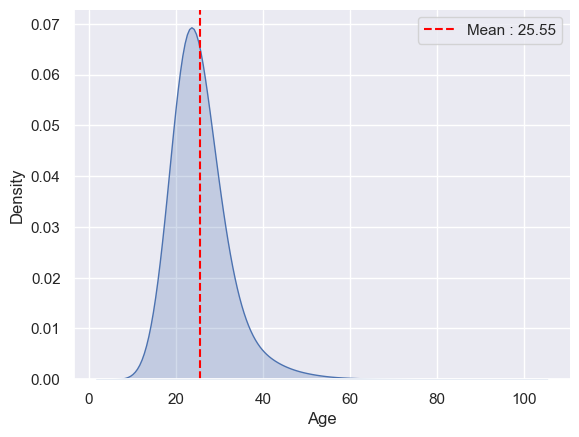

In [48]:
plt.figure()

sns.set_theme(context='notebook',style='dark')
sns.kdeplot(age,bw_adjust=5,fill=True)
sns.despine() 

mean = age.mean()

plt.axvline(mean, color='red', linestyle='--',label=f'Mean : {mean:.2f}')
plt.legend()

plt.grid()

plt.show()

### Age Distibution of Athletes based on Medal

In [49]:
medalist  = df[df['Medal'].notna()]
ua = ua.dropna(subset='Age')

gm = ua[ua['Medal']=='Gold'] #gold medalist
sm = ua[ua['Medal']=='Silver'] #silver medalist
bm = ua[ua['Medal']=='Bronze'] #silver medalist

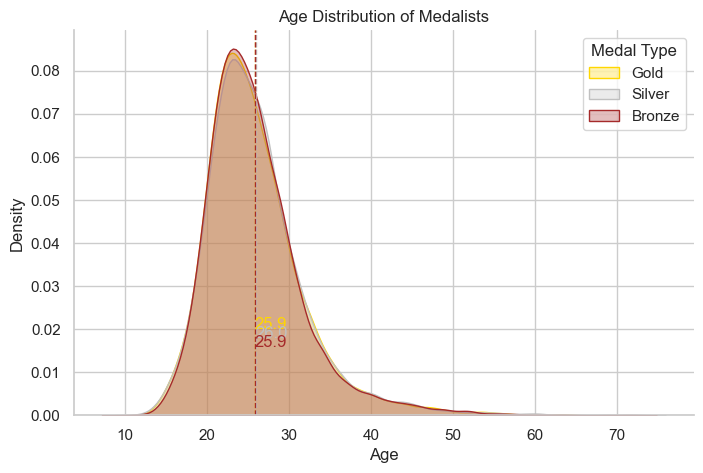

In [50]:
gm_mean = gm['Age'].mean()
sm_mean = sm['Age'].mean()
bm_mean = bm['Age'].mean()

plt.figure(figsize=(8,5))

sns.set_style("whitegrid")

sns.kdeplot(gm, x='Age', color='gold', linewidth=1, fill=True, alpha=0.3, label='Gold')
sns.kdeplot(sm, x='Age', color='silver', linewidth=1, fill=True, alpha=0.3, label='Silver')
sns.kdeplot(bm, x='Age', color='brown', linewidth=1, fill=True, alpha=0.3, label='Bronze')

plt.axvline(gm_mean, color='gold', linestyle='--', linewidth=1)
plt.axvline(sm_mean, color='silver', linestyle='--', linewidth=1)
plt.axvline(bm_mean, color='brown', linestyle='--', linewidth=1)

plt.text(gm_mean, 0.02, f'{gm_mean:.1f}', color='gold')
plt.text(sm_mean, 0.018, f'{sm_mean:.1f}', color='silver')
plt.text(bm_mean, 0.016, f'{bm_mean:.1f}', color='brown')

plt.title("Age Distribution of Medalists")
plt.xlabel("Age")
plt.ylabel("Density")

sns.despine()
plt.legend(title='Medal Type')

plt.show()

### Age Distribution of Athletes based on Sports

In [51]:
sports = df['Sport'].dropna().unique()
sports = sorted(sports)
afs_dict = dict() #afs - athlete from given sport
for sport in sports:
    afs = df[df['Sport']==sport] 
    afs_age = afs['Age'].dropna().tolist()
    afs_dict[sport] = afs_age

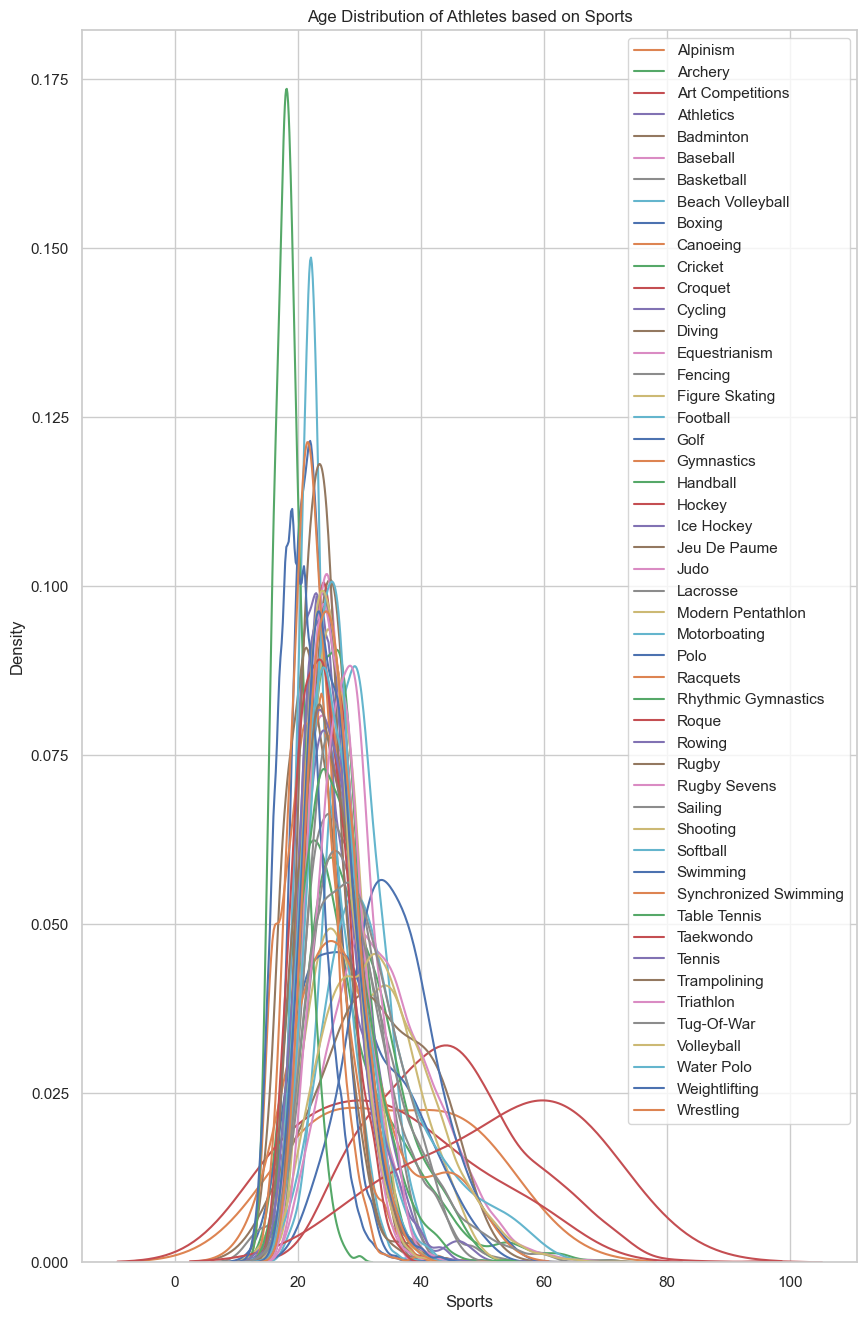

In [52]:

plt.figure(figsize=(10,16))

sns.set_style('whitegrid')

for sport,ages in afs_dict.items():
    ages = pd.DataFrame(ages,columns=[sport])
    sns.kdeplot(ages,x=sport,label=sport,warn_singular=False)

plt.title('Age Distribution of Athletes based on Sports')
plt.xlabel('Sports')

plt.legend()
plt.show()

### Medal Distribution based on Height - Weight Specs of Athletes 

In [53]:
sport = 'Swimming' # write Overall for all sports
wdf = df.copy() #working data frame
if sport != 'Overall':
    wdf = df[df['Sport']==sport]
wdf = wdf.dropna(subset=['Height','Weight'])
wdf.fillna({'Medal':'No Medal'},inplace = True)
wdf.reset_index(inplace=True,drop=True)
wdf.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,36,Stefan Remco Aartsen,M,21.0,194.0,78.0,Netherlands,NED,1996 Summer,1996,Summer,Atlanta,Swimming,Swimming Men's 100 metres Butterfly,No Medal,Netherlands,NaN,False,False,False
1,36,Stefan Remco Aartsen,M,21.0,194.0,78.0,Netherlands,NED,1996 Summer,1996,Summer,Atlanta,Swimming,Swimming Men's 200 metres Butterfly,No Medal,Netherlands,NaN,False,False,False
2,36,Stefan Remco Aartsen,M,21.0,194.0,78.0,Netherlands,NED,1996 Summer,1996,Summer,Atlanta,Swimming,Swimming Men's 4 x 100 metres Medley Relay,No Medal,Netherlands,NaN,False,False,False
3,36,Stefan Remco Aartsen,M,25.0,194.0,78.0,Netherlands,NED,2000 Summer,2000,Summer,Sydney,Swimming,Swimming Men's 100 metres Butterfly,No Medal,Netherlands,NaN,False,False,False
4,36,Stefan Remco Aartsen,M,25.0,194.0,78.0,Netherlands,NED,2000 Summer,2000,Summer,Sydney,Swimming,Swimming Men's 200 metres Butterfly,No Medal,Netherlands,NaN,False,False,False


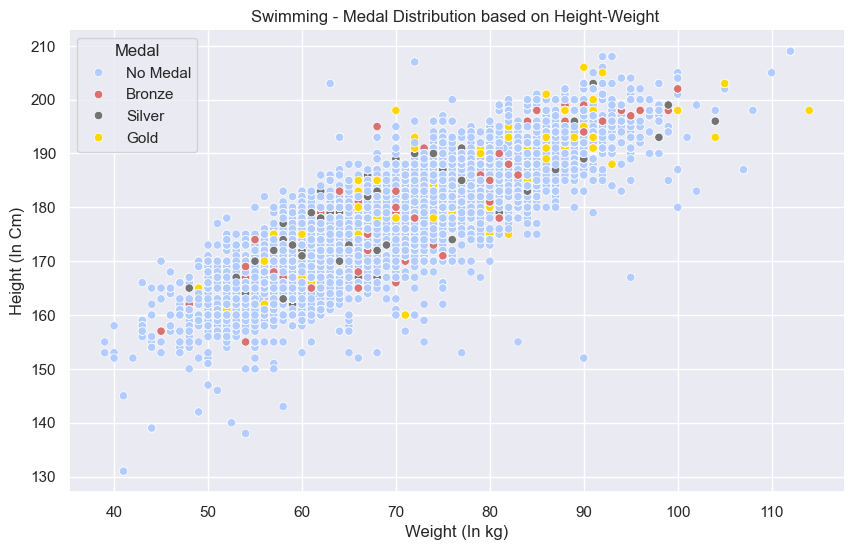

In [54]:
plt.figure(figsize=(10,6))

sns.set_style('darkgrid')
sns.scatterplot(data=wdf,x='Weight',y='Height',hue='Medal',palette={'Gold':'#ffd700','Silver':'#737373','Bronze':'#da7171','No Medal':'#b3ccff'})
sns.despine()

plt.title(f'{sport} - Medal Distribution based on Height-Weight ')
plt.xlabel('Weight (In kg)')
plt.ylabel('Height (In Cm)')

plt.show()

### Men vs Women Participation Over the Years

In [55]:
sport = 'Overall'
wdf = df.copy()
if(sport!='Overall'):
    wdf = wdf[wdf['Sport']==sport]
wdf = wdf.dropna(subset=['Sex'])

wdf = wdf.pivot_table(index = 'Year',columns = 'Sex',values='ID',aggfunc='count')
wdf = wdf.fillna({'F':0,'M':0}).astype('int')
wdf = wdf.reset_index()
wdf.head()

Sex,Year,F,M
0,1896,0,380
1,1900,33,1865
2,1904,16,1285
3,1906,11,1722
4,1908,47,3022


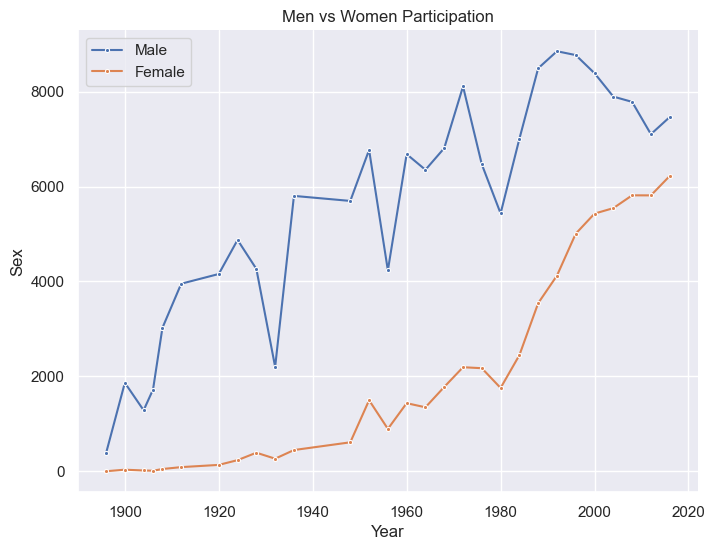

In [56]:
plt.figure(figsize=(8,6))

sns.lineplot(data=wdf , x='Year',y='M',marker='.',label='Male')
sns.lineplot(data=wdf , x='Year',y='F',marker='.',label='Female')
sns.despine()

plt.title('Men vs Women Participation')
plt.xlabel('Year')
plt.ylabel('Sex')

plt.show()

# 📌 Conclusion

This analysis provided a detailed look into the historical trends of the Olympic Games, covering participation growth, medal distribution, and athlete-level patterns.

We observed how the number of participating nations and athletes has evolved over time, along with differences in performance across countries and sports. The analysis of athlete attributes also gave useful insights into how physical characteristics vary across events.

While the dataset offers a strong historical perspective, it is limited to data up to 2016. Extending this analysis with more recent Olympic data (2020 and 2024) could provide a more updated view.

Overall, this project helped in building a strong understanding of data cleaning, exploratory analysis, and visualization, along with translating insights into an interactive dashboard using Streamlit.